# Preprocess 

## import

In [1]:
%matplotlib inline
import math
import warnings

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import tensorflow as tf

print("GPUs Available: ", tf.config.list_physical_devices("GPU"))

plt.rcParams["font.size"] = 14
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (22, 5)

import mlflow
import mlflow.keras

mlflow.set_tracking_uri("file:/mnt/D/Project/Private/Dloss/mlruns")

import json
import math
import os

import keras_tuner
import keras_tuner as kt
import numpy as np
import pandas as pd
import pandas_ta as ta
import seaborn as sns
import tensorflow as tf
from keras_tuner import Hyperband, RandomSearch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint  # type: ignore
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input  # type: ignore
from tensorflow.keras.losses import MeanAbsoluteError, MeanSquaredError
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.models import Model

2025-03-11 13:21:51.465108: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-11 13:21:51.566999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741686711.607043   12711 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741686711.620248   12711 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-11 13:21:51.737278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Params

In [2]:
NORM_MIN, NORM_MAX = 0, 1
MINUTE_INTERVAL = 60
VAL_SIZE = 1000
LOOKBACK_STEPS = 32
SHIFTING_LOOKBACK_STEPS = 1
SHIFTING_TARGET_STEPS = 0
cap_percentage, ceil_percentage = 5, 5
# Define features and target
target_col = "Close_Percent_Change"
str_date = '2018-01-01'

## Download Dataset

In [21]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [22]:
!kaggle datasets download -d mczielinski/bitcoin-historical-data -p data/ --unzip
!rm -rvf data/data/

403 - Forbidden


## Reading csv

In [3]:
df = pd.read_csv("data/btcusd_1-min_data.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")
df.set_index("Timestamp", inplace=True)

In [4]:
df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2025-01-06 23:57:00,102230.0,102232.0,102230.0,102232.0,0.199451
2025-01-06 23:58:00,102262.0,102280.0,102260.0,102280.0,0.104410
2025-01-06 23:59:00,102280.0,102280.0,102280.0,102280.0,0.007554
2025-01-07 00:00:00,102278.0,102291.0,102263.0,102263.0,0.523107
NaT,57854.0,57864.0,57835.0,57835.0,1.353466


## Feature Engineering

In [5]:
df1 = df.dropna()
df1 = df1.iloc[::MINUTE_INTERVAL]  # selecting every th row means every min_interval minutes
df = df1
df["Pos/Neg"] = df.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
df["Close_Percent_Change"] = df["Close"].pct_change() * 100
df = df[
    (df["Close_Percent_Change"] < cap_percentage)
    & (df["Close_Percent_Change"] > -ceil_percentage)
]
df = df[37:]
df["Close_Percent_Change"] = df["Close_Percent_Change"] + 5
# Calculate rolling means
weekly_mean = df.rolling(7).mean()
quarterly_mean = df.rolling(90).mean()
annual_mean = df.rolling(365).mean()
# Compute the rolling mean ratios and other ratios
df["weekly_mean"] = weekly_mean["Close"] / df["Close"]
df["quarterly_mean"] = quarterly_mean["Close"] / df["Close"]
df["annual_mean"] = annual_mean["Close"] / df["Close"]
# Adding Annual and weekly trends
df["annual_weekly_mean"] = df["annual_mean"] / df["weekly_mean"]
df["annual_quarterly_mean"] = df["annual_mean"] / df["quarterly_mean"]
# Calculate ratio of open and close
df["open_close_ratio"] = df["Open"] / df["Close"]
# Calculate ratio of high and close
df["high_close_ratio"] = df["High"] / df["Close"]
# Calculate ratio of low and close
df["low_close_ratio"] = df["Low"] / df["Close"]
print(":::::::::::::pos/neg count:::::::::::::")
# Count the occurrences of each class in the 'Pos/Neg' column
counts = df["Pos/Neg"].value_counts()
print(counts)
print("::::::::::::: oscilators ::::::::::::::::")
df["RSI"] = ta.rsi(df["Close"], length=14)
df["EMAF"] = ta.ema(df["Close"], length=14)
df["EMAM"] = ta.ema(df["Close"], length=42)
df["EMAD"] = ta.ema(df["Close"], length=84)
print(":::::::::::::null count::::::::::::::::")
# First, use forward fill
df.fillna(method="ffill", inplace=True)
print(df.isnull().sum())
print(":::::::::::::dataframe:::::::::::::::::")
df = df[df.index > str_date]
df.head(5)

:::::::::::::pos/neg count:::::::::::::
Pos/Neg
0.0    56981
1.0    54792
Name: count, dtype: int64
::::::::::::: oscilators ::::::::::::::::
:::::::::::::null count::::::::::::::::
Open                       0
High                       0
Low                        0
Close                      0
Volume                     0
Pos/Neg                    0
Close_Percent_Change       0
weekly_mean                6
quarterly_mean            89
annual_mean              364
annual_weekly_mean       364
annual_quarterly_mean    364
open_close_ratio           0
high_close_ratio           0
low_close_ratio            0
RSI                       16
EMAF                      13
EMAM                      41
EMAD                      83
dtype: int64
:::::::::::::dataframe:::::::::::::::::


,Open,High,Low,Close,Volume,Pos/Neg,Close_Percent_Change,weekly_mean,quarterly_mean,annual_mean,annual_weekly_mean,annual_quarterly_mean,open_close_ratio,high_close_ratio,low_close_ratio,RSI,EMAF,EMAM,EMAD
Timestamp,,,,,,,,,,,,,,,,,,,
2018-01-01 00:01:00,13821.05,13888.90,13821.05,13850.67,18.083867,0.0,3.933428,0.978618,0.999017,1.130371,1.155069,1.131483,0.997861,1.002760,0.997861,60.837019,13391.255129,13383.682391,13717.860529
2018-01-01 01:01:00,13948.95,13989.00,13948.95,13989.00,3.168651,1.0,5.998724,0.977413,0.987997,1.118513,1.144361,1.132102,0.997137,1.000000,0.997137,62.867077,13470.954445,13411.836698,13724.240281
2018-01-01 02:01:00,14086.00,14099.50,14011.55,14039.99,11.686913,1.0,5.364501,0.983183,0.983491,1.113769,1.132820,1.132466,1.003277,1.004239,0.997974,63.615762,13546.825853,13441.053131,13731.669686
2018-01-01 03:01:00,14023.99,14023.99,13982.53,14023.96,3.328342,0.0,4.885826,0.991265,0.983489,1.114323,1.124142,1.133031,1.000002,1.000002,0.997046,63.184458,13610.443739,13468.165078,13738.547106
2018-01-01 04:01:00,13924.98,13924.98,13924.98,13924.98,0.362685,0.0,4.294208,1.003531,0.990007,1.121478,1.117532,1.132798,1.000000,1.000000,1.000000,60.458766,13652.381907,13489.412284,13742.933762


## Scaling And Spliting 

In [6]:
features = df.columns[df.columns != target_col]

# Get the column indices for features and target
feature_indices = [df.columns.get_loc(col) for col in features]
target_index = df.columns.get_loc(target_col)

# Update the create_sequences function
def create_sequences(
    data,
    target_index,
    feature_indices,
    lookback_steps,
    shifting_lookback_steps,
    shifting_target_steps=0,
):
    X, y = [], []
    for i in range(
        0,
        math.ceil((len(data) - lookback_steps) / shifting_lookback_steps)
        - shifting_target_steps,
    ):
        start_idx = i * shifting_lookback_steps
        end_idx = start_idx + lookback_steps
        X.append(data[start_idx:end_idx, feature_indices])
        y.append(data[start_idx + lookback_steps + shifting_target_steps, target_index])
    return np.array(X), np.array(y)


# Split train and val

train, val = df[:-VAL_SIZE], df[-VAL_SIZE:]

# Define separate scalers for features and target
scaler_X = StandardScaler()  # For features
scaler_y = StandardScaler()  # For target

# Fit and scale features and target
train_X, train_y, val_X, val_y = (
    train[features],
    train[[target_col]],
    val[features],
    val[[target_col]],
)

train_X_scaled = scaler_X.fit_transform(train_X)
train_y_scaled = scaler_y.fit_transform(train_y)

val_X_scaled = scaler_X.transform(val_X)
val_y_scaled = scaler_y.transform(val_y)

# Create sequences
X_train_scaled, y_train_scaled = create_sequences(
    np.hstack([train_X_scaled, train_y_scaled]),
    target_index=len(features),
    feature_indices=list(range(len(features))),
    lookback_steps=LOOKBACK_STEPS,
    shifting_lookback_steps=SHIFTING_LOOKBACK_STEPS,
    shifting_target_steps=SHIFTING_TARGET_STEPS,
)

X_val_scaled, y_val_scaled = create_sequences(
    np.hstack([val_X_scaled, val_y_scaled]),
    target_index=len(features),
    feature_indices=list(range(len(features))),
    lookback_steps=LOOKBACK_STEPS,
    shifting_lookback_steps=SHIFTING_LOOKBACK_STEPS,
    shifting_target_steps=SHIFTING_TARGET_STEPS,
)

# Fit and transform the training data
X_train_scaled = X_train_scaled.reshape(-1, X_train_scaled.shape[-1]).reshape(
    X_train_scaled.shape
)
# y_train_scaled = y_train_scaled.reshape(-1, 1)
y_train_scaled = y_train_scaled.reshape(-1, 1)
y_val_scaled = y_val_scaled.reshape(-1, 1)

# Transform the validation data
X_val_scaled = X_val_scaled.reshape(-1, X_val_scaled.shape[-1]).reshape(
    X_val_scaled.shape
)


## Statistic and Visualization

In [7]:
# Summary statistics
print("Train Target Summary:\n", train_y.describe())
print("Validation Target Summary:\n", val_y.describe())

Train Target Summary:
        Close_Percent_Change
count          58630.000000
mean               5.004410
std                0.705465
min                0.034770
25%                4.744902
50%                5.004618
75%                5.268989
max                9.997658
Validation Target Summary:
        Close_Percent_Change
count           1000.000000
mean               5.030010
std                0.683289
min                0.515608
25%                4.781786
50%                5.018330
75%                5.288260
max                9.496773


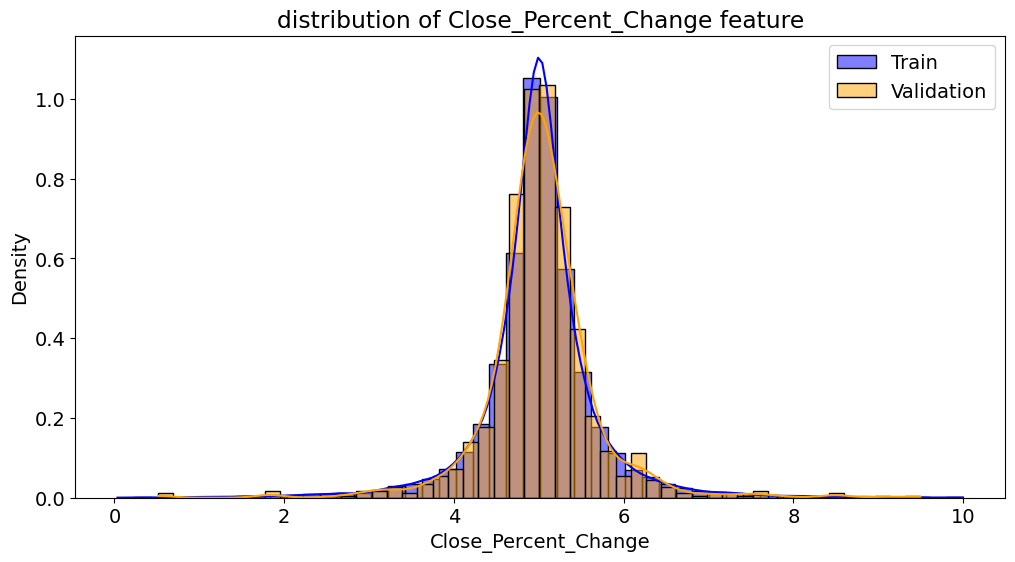

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(
    train_y[target_col],
    bins=50,
    kde=True,
    color="blue",
    label="Train",
    stat="density",
)
sns.histplot(
    val_y[target_col],
    bins=50,
    kde=True,
    color="orange",
    label="Validation",
    stat="density",
)
plt.xlabel(target_col)
plt.ylabel("Density")
plt.title(f"distribution of {target_col} feature")
plt.legend()
plt.show()

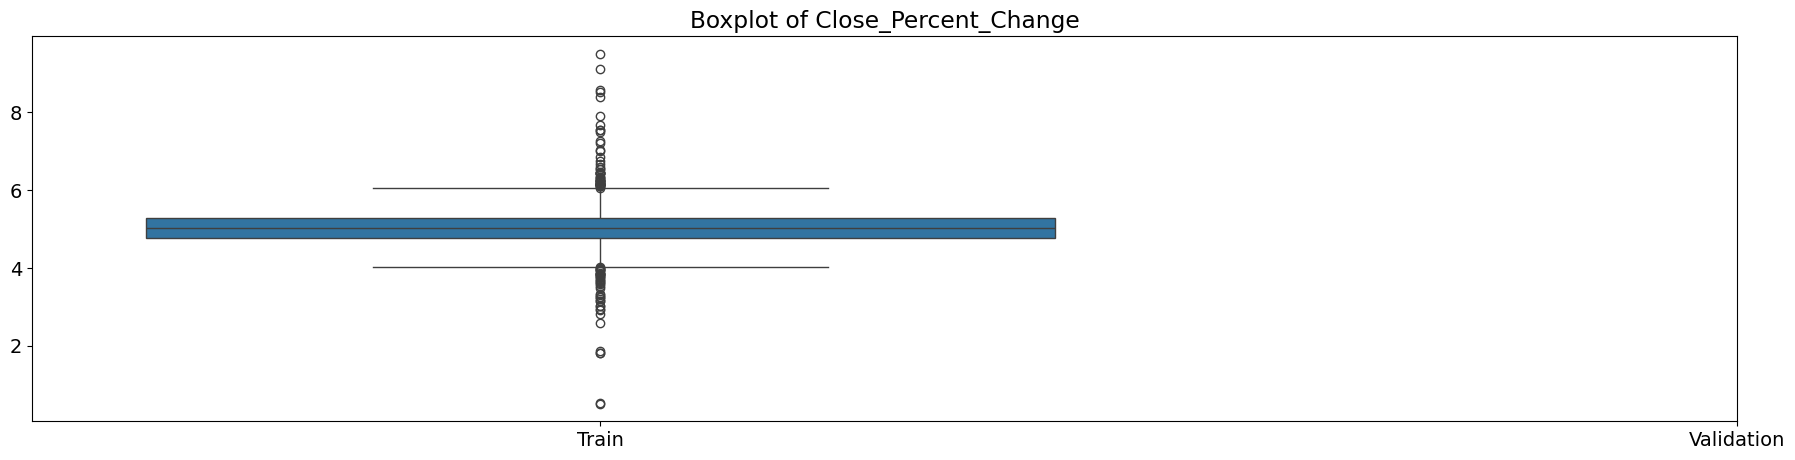

In [9]:
sns.boxplot(data=[train_y[target_col], val_y[target_col]])
plt.xticks([0, 1], ["Train", "Validation"])
plt.title(f"Boxplot of {target_col}")
plt.show()

In [10]:
Q1_train = train_y[target_col].quantile(0.25)
Q3_train = train_y[target_col].quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_bound_train = Q1_train - 1.5 * IQR_train
upper_bound_train = Q3_train + 1.5 * IQR_train

print(
    "Outliers in Training Data:",
    train_y[
        (train_y[target_col] < lower_bound_train)
        | (train_y[target_col] > upper_bound_train)
    ],
)

Outliers in Training Data:                      Close_Percent_Change
Timestamp                                
2018-01-01 00:01:00              3.933428
2018-01-01 06:01:00              3.477081
2018-01-01 07:01:00              3.266599
2018-01-01 10:01:00              6.267892
2018-01-01 12:01:00              6.828536
...                                   ...
2024-09-10 01:21:00              6.365554
2024-09-11 18:21:00              2.761286
2024-09-11 20:21:00              6.500427
2024-09-11 21:21:00              6.195925
2024-09-13 16:21:00              6.979877

[5748 rows x 1 columns]


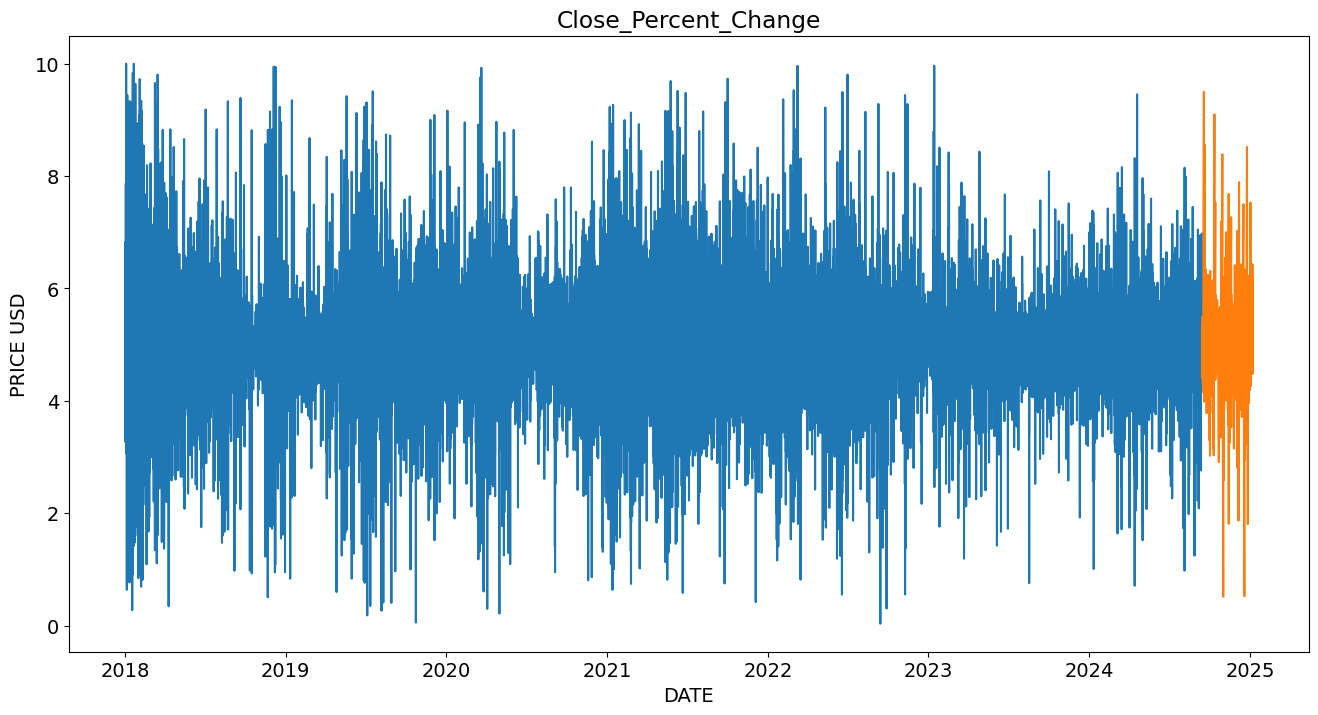

In [11]:
plt.figure(figsize=(16, 8))
plt.title(target_col)
plt.plot(train_y[target_col])
plt.plot(val_y[target_col])
plt.xlabel("DATE")
plt.ylabel("PRICE USD")
plt.show()

# Training

## Callbacks

In [12]:
path = f"data/ModelCheckpoint/"

# Define the model checkpoint callback
checkpoint_cb = ModelCheckpoint(
    filepath=f"{path}/model_epoch_{{epoch:02d}}_val_loss_{{val_loss:.2f}}.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="loss", patience=20, restore_best_weights=True
)

initial_lr = 1e-4  # Set your initial learning rate
# Learning rate schedule with warm-up and decay
def lr_schedule_with_warmup(epoch, lr):
    warmup_epochs = 5  # Number of warm-up epochs
    if epoch < warmup_epochs:
        return initial_lr * (epoch + 1) / warmup_epochs  # Gradual increase
    else:
        return lr * 0.8  # Decay by a factor of 0.8 after warm-up


# Use the custom learning rate schedule
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lr_schedule_with_warmup)


class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_dir, validation_data=None):
        super().__init__()
        self.log_dir = log_dir
        self.validation_data = validation_data  # Add validation_data as a parameter

    def on_epoch_end(self, epoch, logs=None):
        if self.validation_data is not None:
            # Use the validation data to compute gradients
            with tf.GradientTape() as tape:
                # Ensure you're using the validation data correctly
                predictions = self.model(self.validation_data[0], training=True)
                loss = self.model.compiled_loss(self.validation_data[1], predictions)
            gradients = tape.gradient(loss, self.model.trainable_variables)

            # Log the gradients or do any other logging as needed
            print(f"Epoch {epoch+1}, Gradients: {gradients}")
        else:
            print(f"Validation data is not provided for gradient logging.")

# Updated ActivationMonitor Callback
class ActivationMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Check if the epoch is a multiple of 10 (print every 10 epochs)
        if (epoch + 1) % 10 == 0:  # epoch is 0-indexed, so add 1 for correct counting
            print(f"--- Epoch {epoch + 1} ---")
            for layer in self.model.layers:
                if isinstance(layer, tf.keras.layers.LSTM):
                    # Create a submodel to get intermediate activations
                    intermediate_model = tf.keras.Model(
                        inputs=self.model.input, outputs=layer.output
                    )
                    # Use a small sample from the training data
                    sample_input = X_train_scaled[:1]  # Adjust as needed
                    activations = intermediate_model(sample_input)
                    print(f"Activations after {layer.name}: {activations.numpy()}")


## Params

In [13]:
BORDER = (NORM_MAX + NORM_MIN) / 2
BATCH_SIZE = 32
EPOCHS = 50

## Dloss Formula

In [14]:
from IPython.display import display, Math

# Define the LaTeX code
latex_code = r"""
\text{dloss} = \left( (\vec{y_{\text{true}}} \cdot \vec{y_{\text{pred}}}) - (\vec{y_{\text{true}}} \cdot \vec{y_{\text{true}}}) \right)^2
"""

latex_code_2 = r"""
\text{dloss} = \left( (y_{\text{pred}} \cdot y_{\text{true}}) + (\operatorname{sign}(y_{\text{pred}}) \cdot \operatorname{sign}(y_{\text{true}})) - \left( y_{\text{true}}^2 + \operatorname{sign}(y_{\text{true}})^2 \right) \right)^2
"""

latex_code_3 = r"""
\operatorname{sign}(x) =
\begin{cases} 
1, & x \geq 0 \\
-1, & x < 0
\end{cases}
"""

# Display the LaTeX
display(Math(latex_code))
display(Math(latex_code_2))
display(Math(latex_code_3))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Dloss Code

In [15]:
import tensorflow as tf

def custom_loss(border=0):
    def loss(y_true, y_pred):
        # Determine sign element-wise
        pos_neg_true = tf.where(y_true >= 0, 1.0, -1.0)
        pos_neg_pred = tf.where(y_pred >= 0, 1.0, -1.0)
        
        # Calculate dmse based on conditions
        dloss = ( (y_true ** 2 + pos_neg_true ** 2) - ((y_pred * y_true) + (pos_neg_pred * pos_neg_true)) ) ** 2

        return tf.reduce_mean(dloss)
    
    return loss


## LSTM With sgd mse

In [16]:
import tensorflow as tf
from tensorflow.keras.initializers import HeNormal
from keras.losses import Huber

tf.config.run_functions_eagerly(True)


# Define the model with residual connections
inputs = tf.keras.Input(shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))

# First LSTM block
x1 = tf.keras.layers.LSTM(450, return_sequences=True,kernel_initializer=HeNormal(), dropout=0.1)(inputs)
x1 = tf.keras.layers.Dropout(0.1)(x1)

# Second LSTM block with residual connection
x2 = tf.keras.layers.LSTM(450, return_sequences=True,kernel_initializer=HeNormal(), dropout=0.1)(x1)
x2 = tf.keras.layers.Dropout(0.1)(x2)
x2 = tf.keras.layers.Add()([x1, x2])  # Residual connection

# Third LSTM block with residual connection
x3 = tf.keras.layers.LSTM(450)(x2)
x3 = tf.keras.layers.Dropout(0.1)(x3)
x3 = tf.keras.layers.Add()([x2[:, -1, :], x3])  # Residual connection (flatten last sequence for compatibility)

# Final Dense layer
outputs = tf.keras.layers.Dense(1, kernel_initializer=HeNormal(), activation=None)(x3)

# Define the model
model_lstm_mse = tf.keras.Model(inputs, outputs)

#optimizer = tf.keras.optimizers.RMSprop(clipnorm=5.0, learning_rate=0.02)
#optimizer = tf.keras.optimizers.Adam(clipnorm=5.0, learning_rate=0.02)  # Clip gradients at 1.0
optimizer = tf.keras.optimizers.SGD(
     learning_rate=1e-4,  # Adjust the learning rate if needed
     momentum=0.9,        # Use momentum for better convergence (optional)
     nesterov=True        # Enable Nesterov momentum (optional)
)


model_lstm_mse.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Display model summary
model_lstm_mse.summary()
# Model training with GradientLogger callback
gradient_logger = GradientLogger(log_dir="logs/gradient_logs")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/gradient_logs", histogram_freq=1)


history_lstm_mse = model_lstm_mse.fit(
        X_train_scaled, y_train_scaled, 
        batch_size=BATCH_SIZE, 
        epochs=EPOCHS, 
        validation_data=(X_val_scaled, y_val_scaled), 
        callbacks=[ActivationMonitor(), gradient_logger, tensorboard_callback, checkpoint_cb, early_stopping_cb, lr_schedule]
        )

I0000 00:00:1741686736.684239   12711 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21131 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32, 450)   │    844,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 450)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32, 450)   │  1,621,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 450)   │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 450)   │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 450)       │  1,621,800 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 450)       │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 450)       │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 450)       │          0 │ get_item[0][0],   │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        451 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,088,251 (15.60 MB)

 Trainable params: 4,088,251 (15.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1741686738.025015   13141 cuda_dnn.cc:529] Loaded cuDNN version 90300


1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.2471 - mae: 0.7651Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - loss: 1.2471 - mae: 0.7650 - val_loss: 1.0665 - val_mae: 0.6882 - learning_rate: 2.0000e-05
Epoch 2/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.1231 - mae: 0.6980Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - loss: 1.1231 - mae: 0.6980 - val_loss: 1.0387 - val_mae: 0.6534 - learning_rate: 4.0000e-05
Epoch 3/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0879 - mae: 0.6771Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - loss: 1.0879 - mae: 0.6771 - val_loss: 0.9935 - val_mae: 0.6366 - learning_rate: 6.0000e-05
Epoch 4/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0483 - mae: 0.6558Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step -

## LSTM with sgd dloss 

In [17]:
import tensorflow as tf
from tensorflow.keras.initializers import HeNormal

tf.config.run_functions_eagerly(True)


# Define the model with residual connections
inputs = tf.keras.Input(shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))

# First LSTM block
x1 = tf.keras.layers.LSTM(450, return_sequences=True, kernel_initializer=HeNormal(), dropout=0.1)(inputs)
x1 = tf.keras.layers.Dropout(0.1)(x1)

# Second LSTM block with residual connection
x2 = tf.keras.layers.LSTM(450, return_sequences=True,kernel_initializer=HeNormal(), dropout=0.1)(x1)
x2 = tf.keras.layers.Dropout(0.1)(x2)
x2 = tf.keras.layers.Add()([x1, x2])  # Residual connection

# Third LSTM block with residual connection
x3 = tf.keras.layers.LSTM(450)(x2)
x3 = tf.keras.layers.Dropout(0.1)(x3)
x3 = tf.keras.layers.Add()([x2[:, -1, :], x3])  # Residual connection (flatten last sequence for compatibility)

# Final Dense layer
outputs = tf.keras.layers.Dense(1, kernel_initializer=HeNormal(), activation=None)(x3)

# Define the model
model_lstm_dloss = tf.keras.Model(inputs, outputs)

#optimizer = tf.keras.optimizers.RMSprop(clipnorm=5.0, learning_rate=0.02)
#optimizer = tf.keras.optimizers.Adam(clipnorm=5.0, learning_rate=0.02)  # Clip gradients at 1.0
optimizer = tf.keras.optimizers.SGD(
    learning_rate=1e-4,  # Adjust the learning rate if needed
    momentum=0.9,        # Use momentum for better convergence (optional)
    nesterov=True        # Enable Nesterov momentum (optional)
 )

model_lstm_dloss.compile(optimizer=optimizer, loss=custom_loss(border=BORDER), metrics=['mae'])

# Display model summary
model_lstm_dloss.summary()
# Model training with GradientLogger callback
gradient_logger = GradientLogger(log_dir="logs/gradient_logs")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/gradient_logs", histogram_freq=1)


history_lstm_dloss = model_lstm_dloss.fit(
        X_train_scaled, y_train_scaled, 
        batch_size=BATCH_SIZE, 
        epochs=EPOCHS, 
        validation_data=(X_val_scaled, y_val_scaled), 
        callbacks=[ActivationMonitor(), gradient_logger, tensorboard_callback, checkpoint_cb, early_stopping_cb, lr_schedule]
        )

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32, 450)   │    844,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 450)   │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32, 450)   │  1,621,800 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 450)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 450)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 450)       │  1,621,800 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 450)       │          0 │ add_2[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 450)       │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 450)       │          0 │ get_item_1[0][0], │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        451 │ add_3[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,088,251 (15.60 MB)

 Trainable params: 4,088,251 (15.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1831/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 16.4614 - mae: 0.8493Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - loss: 16.4607 - mae: 0.8493 - val_loss: 16.7989 - val_mae: 0.7270 - learning_rate: 2.0000e-05
Epoch 2/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.4723 - mae: 0.8682Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - loss: 15.4724 - mae: 0.8682 - val_loss: 16.8306 - val_mae: 0.6980 - learning_rate: 4.0000e-05
Epoch 3/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.5140 - mae: 0.8633Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 56s 31ms/step - loss: 15.5141 - mae: 0.8633 - val_loss: 17.2742 - val_mae: 0.6891 - learning_rate: 6.0000e-05
Epoch 4/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.2396 - mae: 0.8773Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━

## LSTM With adam mse

In [18]:
import tensorflow as tf
# Third LSTM block with residual connection
x3 = tf.keras.layers.LSTM(450)(x2)
x3 = tf.keras.layers.Dropout(0.1)(x3)
x3 = tf.keras.layers.Add()([x2[:, -1, :], x3])  # Residual connection (flatten last sequence for compatibility)

# Final Dense layer
outputs = tf.keras.layers.Dense(1, kernel_initializer=HeNormal(), activation=None)(x3)

# Define the model
model_lstm_mse_adam = tf.keras.Model(inputs, outputs)

#optimizer = tf.keras.optimizers.RMSprop(clipnorm=5.0, learning_rate=0.02)
optimizer = tf.keras.optimizers.Adam(clipnorm=5.0, learning_rate=0.02)  # Clip gradients at 1.0
# optimizer = tf.keras.optimizers.SGD(
#      learning_rate=1e-4,  # Adjust the learning rate if needed
#      momentum=0.9,        # Use momentum for better convergence (optional)
#      nesterov=True        # Enable Nesterov momentum (optional)
# )


model_lstm_mse_adam.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Display model summary
model_lstm_mse_adam.summary()
# Model training with GradientLogger callback
gradient_logger = GradientLogger(log_dir="logs/gradient_logs")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/gradient_logs", histogram_freq=1)


history_lstm_mse_adam = model_lstm_mse_adam.fit(
        X_train_scaled, y_train_scaled, 
        batch_size=BATCH_SIZE, 
        epochs=EPOCHS, 
        validation_data=(X_val_scaled, y_val_scaled), 
        callbacks=[ActivationMonitor(), gradient_logger, tensorboard_callback, checkpoint_cb, early_stopping_cb, lr_schedule]
        )

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32, 450)   │    844,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 450)   │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32, 450)   │  1,621,800 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 450)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 450)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 450)       │  1,621,800 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 450)       │          0 │ add_2[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 450)       │          0 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 450)       │          0 │ get_item_2[0][0], │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        451 │ add_4[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,088,251 (15.60 MB)

 Trainable params: 4,088,251 (15.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.1649 - mae: 0.7233Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 73s 40ms/step - loss: 1.1649 - mae: 0.7233 - val_loss: 1.0065 - val_mae: 0.6324 - learning_rate: 2.0000e-05
Epoch 2/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.0784 - mae: 0.6790Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 74s 40ms/step - loss: 1.0784 - mae: 0.6790 - val_loss: 1.0159 - val_mae: 0.6359 - learning_rate: 4.0000e-05
Epoch 3/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.0473 - mae: 0.6651Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 75s 41ms/step - loss: 1.0473 - mae: 0.6651 - val_loss: 0.9742 - val_mae: 0.6178 - learning_rate: 6.0000e-05
Epoch 4/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.0166 - mae: 0.6479Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 73s 

## LSTM With adam dloss

In [19]:
import tensorflow as tf
x2 = tf.keras.layers.Dropout(0.1)(x2)
x2 = tf.keras.layers.Add()([x1, x2])  # Residual connection

# Third LSTM block with residual connection
x3 = tf.keras.layers.LSTM(450)(x2)
x3 = tf.keras.layers.Dropout(0.1)(x3)
x3 = tf.keras.layers.Add()([x2[:, -1, :], x3])  # Residual connection (flatten last sequence for compatibility)

# Final Dense layer
outputs = tf.keras.layers.Dense(1, kernel_initializer=HeNormal(), activation=None)(x3)

# Define the model
model_lstm_dloss_adam = tf.keras.Model(inputs, outputs)

#optimizer = tf.keras.optimizers.RMSprop(clipnorm=5.0, learning_rate=0.02)
optimizer = tf.keras.optimizers.Adam(clipnorm=5.0, learning_rate=0.02)  # Clip gradients at 1.0
# optimizer = tf.keras.optimizers.SGD(
#     learning_rate=1e-4,  # Adjust the learning rate if needed
#     momentum=0.9,        # Use momentum for better convergence (optional)
#     nesterov=True        # Enable Nesterov momentum (optional)
#  )

model_lstm_dloss_adam.compile(optimizer=optimizer, loss=custom_loss(border=BORDER), metrics=['mae'])

# Display model summary
model_lstm_dloss_adam.summary()
# Model training with GradientLogger callback
gradient_logger = GradientLogger(log_dir="logs/gradient_logs")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/gradient_logs", histogram_freq=1)


history_lstm_dloss_adam = model_lstm_dloss_adam.fit(
        X_train_scaled, y_train_scaled, 
        batch_size=BATCH_SIZE, 
        epochs=EPOCHS, 
        validation_data=(X_val_scaled, y_val_scaled), 
        callbacks=[ActivationMonitor(), gradient_logger, tensorboard_callback, checkpoint_cb, early_stopping_cb, lr_schedule]
        )

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32, 450)   │    844,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 450)   │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32, 450)   │  1,621,800 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 450)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 450)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32, 450)   │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 450)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 450)       │  1,621,800 │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 450)       │          0 │ add_5[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 450)       │          0 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 450)       │          0 │ get_item_3[0][0], │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        451 │ add_6[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,088,251 (15.60 MB)

 Trainable params: 4,088,251 (15.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1831/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 16.6868 - mae: 0.8617Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 75s 41ms/step - loss: 16.6855 - mae: 0.8617 - val_loss: 17.4881 - val_mae: 0.7225 - learning_rate: 2.0000e-05
Epoch 2/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.1235 - mae: 0.8054Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 76s 42ms/step - loss: 15.1235 - mae: 0.8054 - val_loss: 16.1744 - val_mae: 0.6894 - learning_rate: 4.0000e-05
Epoch 3/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.3215 - mae: 0.7959Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - loss: 15.3212 - mae: 0.7959 - val_loss: 16.4116 - val_mae: 0.7121 - learning_rate: 6.0000e-05
Epoch 4/50
1832/1832 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 14.4283 - mae: 0.7638Validation data is not provided for gradient logging.
1832/1832 ━━━━━━━━━━━━━━━

# Validation

## prediction SGD

In [20]:
y_val_pred_scaled_lstm_dloss = model_lstm_dloss.predict(X_val_scaled)  
y_val_pred_scaled_lstm_mse = model_lstm_mse.predict(X_val_scaled)  
y_val_pred_scaled_lstm_mse_adam = model_lstm_mse_adam.predict(X_val_scaled)  
y_val_pred_scaled_lstm_dloss_adam = model_lstm_dloss_adam.predict(X_val_scaled)  

y_pred_lstm_dloss = scaler_y.inverse_transform(y_val_pred_scaled_lstm_dloss).flatten()
y_pred_lstm_mse = scaler_y.inverse_transform(y_val_pred_scaled_lstm_mse).flatten()

y_yal_original = scaler_y.inverse_transform(y_val_scaled).flatten()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


## Ploting SGD

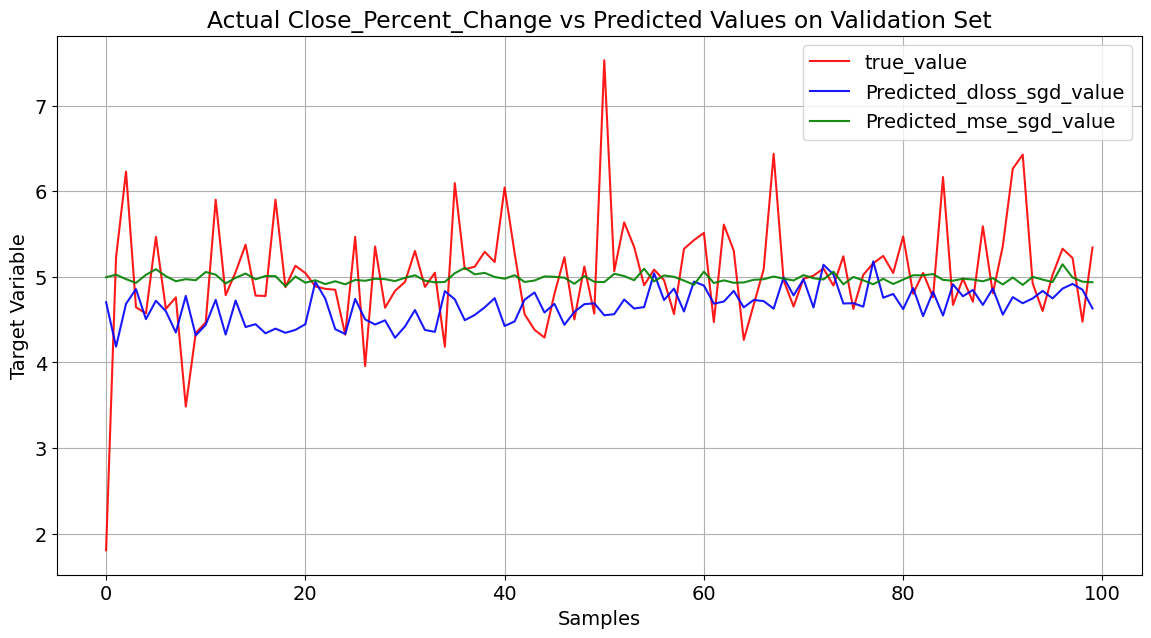

In [21]:
# Plotting the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_yal_original[-100:], label='true_value', color='red', alpha=0.9)
plt.plot(y_pred_lstm_dloss[-100:], label='Predicted_dloss_sgd_value', color='blue', alpha=0.9)
plt.plot(y_pred_lstm_mse[-100:], label='Predicted_mse_sgd_value', color='green', alpha=0.9)

plt.title(f"Actual {target_col} vs Predicted Values on Validation Set")
plt.xlabel('Samples')
plt.ylabel('Target Variable')
plt.legend()
plt.grid()
plt.savefig("actual_dloss_mse_sgd.png", dpi=500, bbox_inches='tight')
plt.show()

## Trend SGD

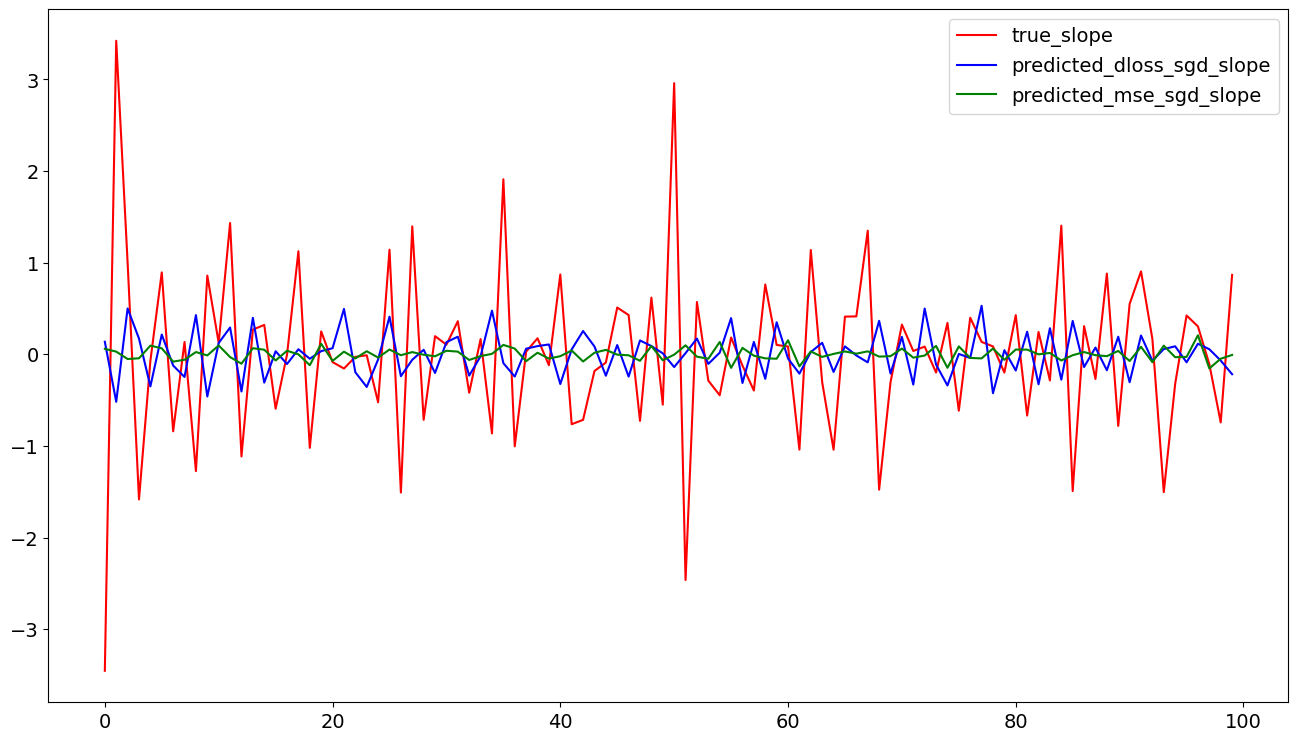

In [22]:
y_pred_lstm_dloss_slope = [y_pred_lstm_dloss[i+1] - y_pred_lstm_dloss[i] for i in range(len(y_pred_lstm_dloss) - 1)]
y_pred_lstm_mse_slope = [y_pred_lstm_mse[i+1] - y_pred_lstm_mse[i] for i in range(len(y_pred_lstm_mse) - 1)]
y_yal_original_slope = [y_yal_original[i+1] - y_yal_original[i] for i in range(len(y_yal_original) - 1)]

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(y_yal_original_slope[-100:], label= 'true_slope', color='red')
ax.plot(y_pred_lstm_dloss_slope[-100:], label='predicted_dloss_sgd_slope', color='blue')
ax.plot(y_pred_lstm_mse_slope[-100:], label='predicted_mse_sgd_slope', color='green')
plt.legend()
fig.savefig("slope_true_dloss_mse_sgd.png", dpi=500, bbox_inches='tight')  # Save the figure
plt.show()


## prediction ADAM

In [23]:
y_val_pred_scaled_lstm_mse_adam = model_lstm_mse_adam.predict(X_val_scaled)  
y_val_pred_scaled_lstm_dloss_adam = model_lstm_dloss_adam.predict(X_val_scaled)  

y_pred_lstm_dloss_adam = scaler_y.inverse_transform(y_val_pred_scaled_lstm_dloss_adam).flatten()
y_pred_lstm_mse_adam = scaler_y.inverse_transform(y_val_pred_scaled_lstm_mse_adam).flatten()

y_yal_original = scaler_y.inverse_transform(y_val_scaled).flatten()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


## Ploting ADAM

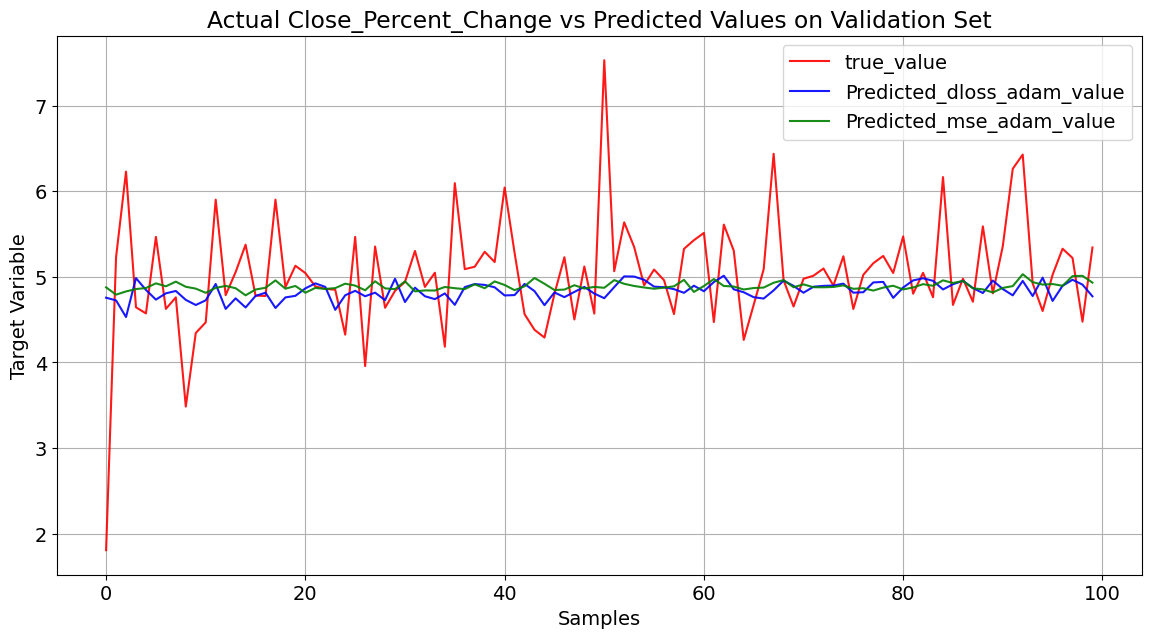

In [24]:
# Plotting the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_yal_original[-100:], label='true_value', color='red', alpha=0.9)
plt.plot(y_pred_lstm_dloss_adam[-100:], label='Predicted_dloss_adam_value', color='blue', alpha=0.9)
plt.plot(y_pred_lstm_mse_adam[-100:], label='Predicted_mse_adam_value', color='green', alpha=0.9)

plt.title(f"Actual {target_col} vs Predicted Values on Validation Set")
plt.xlabel('Samples')
plt.ylabel('Target Variable')
plt.legend()
plt.grid()
plt.savefig("actual_dloss_mse_adam.png", dpi=500, bbox_inches='tight')
plt.show()

## Trend ADAM

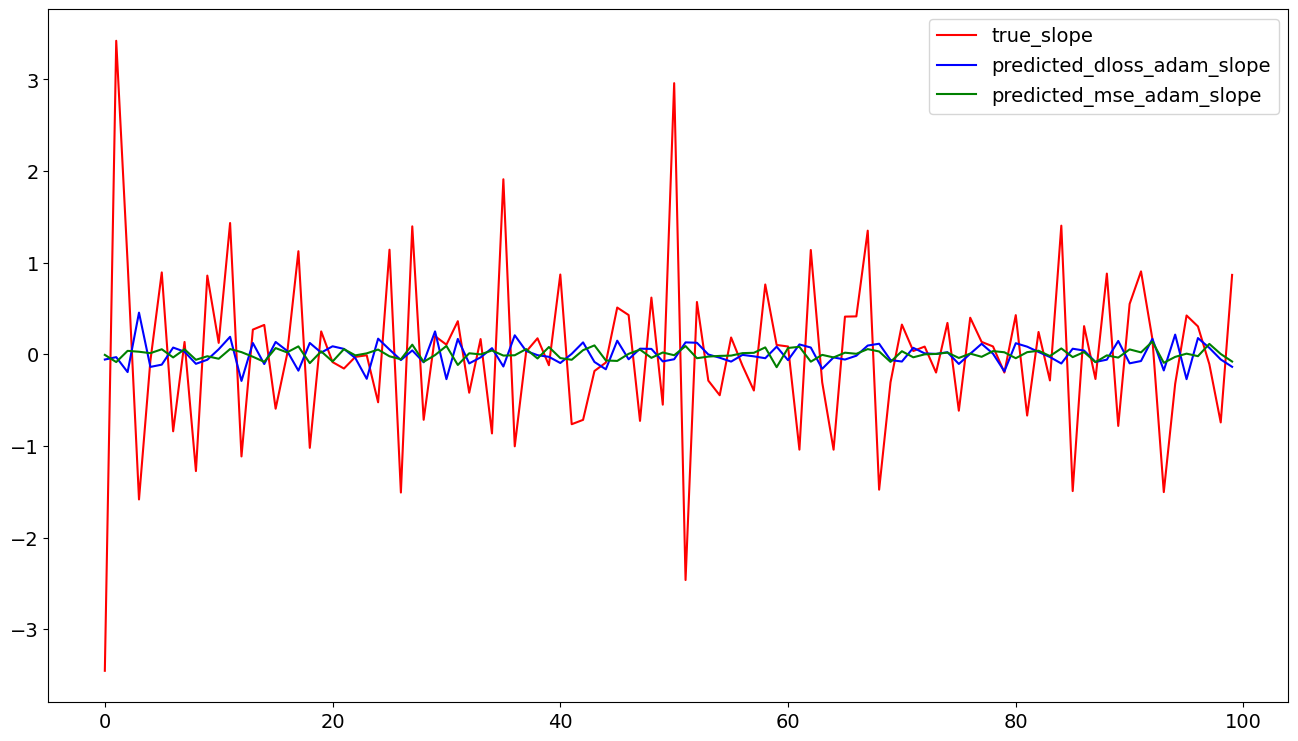

In [25]:
y_pred_lstm_dloss_adam_slope = [y_pred_lstm_dloss_adam[i+1] - y_pred_lstm_dloss_adam[i] for i in range(len(y_pred_lstm_dloss_adam) - 1)]
y_pred_lstm_mse_adam_slope = [y_pred_lstm_mse_adam[i+1] - y_pred_lstm_mse_adam[i] for i in range(len(y_pred_lstm_mse_adam) - 1)]
y_yal_original_slope = [y_yal_original[i+1] - y_yal_original[i] for i in range(len(y_yal_original) - 1)]

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(y_yal_original_slope[-100:], label= 'true_slope', color='red')
ax.plot(y_pred_lstm_dloss_adam_slope[-100:], label='predicted_dloss_adam_slope', color='blue')
ax.plot(y_pred_lstm_mse_adam_slope[-100:], label='predicted_mse_adam_slope', color='green')
plt.legend()
fig.savefig("slope_true_dloss_mse_adam.png", dpi=500, bbox_inches='tight')  # Save the figure
plt.show()
